# Aerosol mass comparison for WRF-Chem-Polar, CAMS, CESM, and MOSAiC
Remake figure 4 with CAMS and CESM output included.

In [ ]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob

# Read measurement data

In [2]:
def read_mosaic_aero_mass(fname, header, species, columns, flag_label, tslice, freq):
    data = pd.read_csv(fname, header=header, sep="\t")
    data["Date/Time"] = pd.to_datetime(data["Date/Time"])
    data = data.set_index("Date/Time").to_xarray()
    data = data.rename(columns)
    data = data.sel(time=tslice)

    data_resample = data.resample(time=freq).mean()
    data_resample = data_resample[species]

    data_masked = data[species].where(data[flag_label]!=1)
    data_masked_resample = data_masked.resample(time=freq).mean()
    
    return data_resample, data_masked_resample

In [3]:
apr = slice(dt.datetime(2020,4,10), dt.datetime(2020,4,20))

ams_columns = {  # used for cleaner column names
    'Date/Time': 'time',
    'Latitude': 'lat',
    'Longitude': 'lon',
    '[SO4]2- [µg/m**3]': 'so4',
    '[NO3]- [µg/m**3]': 'no3',
    '[NH4]+ [µg/m**3]': 'nh4',
    'Cl- [µg/m**3]': 'cl',
    'Org aerosol [µg/m**3]': 'org',
    'QF [NH4]+': 'nh4_qc',  # 1=good, 0=bad
    'Flag pollution': 'pollution_qc'  # 1=polluted, 0=non polluted
}
flag = "pollution_qc"
ams_fname = "/mnt/data/mosaic/AMS_5species_noscaling.tab"
ams_data_1h, ams_masked_1h = read_mosaic_aero_mass(ams_fname, 51, ["so4","org"], ams_columns, flag, apr, "1h")

ebc_columns = {
    'Date/Time': 'time',
    'Latitude': 'lat',
    'Longitude': 'lon',
    'eBC [ng/m**3]': 'ebc',
    'Flag pollution': 'pollution_qc'  # 1=polluted, 0=non polluted
}
ebc_fname = "/mnt/data/mosaic//MOSAiC_eBC.tab"
ebc_data_1h, ebc_masked_1h = read_mosaic_aero_mass(ebc_fname, 42, "ebc", ebc_columns, flag, apr, "1h")


# Read model output

In [4]:
wrfout = xr.open_mfdataset(glob.glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.nc")).sel(Time=apr)

wrfout["rho_air"] = wrfout.wrf.density_of_dry_air[:]
wrfout["air_temperature"] = wrfout.wrf.air_temperature[:]

/tmp/ipykernel_15121/1121732204.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  wrfout = xr.open_mfdataset(glob.glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.nc")).sel(Time=apr)
/tmp/ipykernel_15121/1121732204.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  wrfout = xr.open_mfdataset(glob.glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.

## interpolate from WRF-Chem-Polar aerosol bins to PM1 size range

In [5]:
def make_bin_dimension(ds_wrf, species, nbins=4):
    aname, cwname = species+"_a", species+"_cw"

    # convert a0X output for this species to one array with new bin dimension
    aer_vars = [v for v in ds_wrf.data_vars if aname in v.lower()]
    array_aer = ds_wrf[aer_vars].to_array(dim="bin")
    array_aer["bin"] = np.arange(nbins)

    # cw0X variables
    cld_vars = [v for v in ds_wrf.data_vars if cwname in v.lower()]
    array_cld = ds_wrf[cld_vars].to_array(dim="bin")
    array_cld["bin"] = np.arange(nbins)

    # add new variables to new dataset
    ds_binned = xr.Dataset()
    ds_binned[species] = array_aer+array_cld

    # add bin size coordinates for new dimension
    [dlo, dmid, dhi] = utils.calc_mosaic_size_bins()    
    ds_binned = ds_binned.assign_coords({
        "Dlo": ("bin", dlo),
        "Dmid": ("bin", dmid),
        "Dhi": ("bin", dhi),
        "dD": ("bin", dhi-dlo)
    })

    return ds_binned

def sum_wrf_aero_bins(ds_binned, cutoff=1):
    if "bin" not in ds_binned.dims:
        msg = "[sum_wrf ERROR] no bin dimension on the dataset"
        raise ValueError(msg)
        return
    nbins = len(ds_binned.bin)
    bin_bounds = np.zeros((nbins+1))
    bin_bounds[:-1] = ds_binned.Dlo.values
    bin_bounds[-1] = ds_binned.Dhi.values[-1]

    # find size bin containing cutoff
    i = np.searchsorted(bin_bounds, cutoff)-1

    # sum up to cutoff
    ds_sum = ds_binned.isel(bin=slice(None,i)).sum(dim="bin")

    # add linear fraction of bin containing cutoff
    ibin_width = ds_binned.Dhi.values[i] - ds_binned.Dlo.values[i]
    f = (cutoff - ds_binned.Dlo.values[i]) / ibin_width
    ds_sum += f*ds_binned.isel(bin=i, drop=True)
    
    return ds_sum



In [28]:
wrfout["so4_mmr"] = sum_wrf_aero_bins(make_bin_dimension(wrfout, "so4")).so4
wrfout["bc_mmr"] = sum_wrf_aero_bins(make_bin_dimension(wrfout, "bc")).bc
wrfout["oc_mmr"] = sum_wrf_aero_bins(make_bin_dimension(wrfout, "oc")).oc
wrfout["toa_mmr"] = sum_wrf_aero_bins(make_bin_dimension(wrfout, "totoa")).totoa

wrfout["so4"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "so4")).so4
wrfout["bc"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "bc")).bc
wrfout["oc"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "oc")).oc
wrfout["toa"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "totoa")).totoa


In [30]:
wrfout_mosaic_mean = wrfout.mean(["i","j"])
wrfout_mosaic_min = wrfout.min(["i","j"])
wrfout_mosaic_max = wrfout.max(["i","j"])

### read CAMS and CESM

In [15]:
cams = xr.open_dataset("/mnt/data/cams/cams_mosaic.nc").sel(time=apr)
cams_mosaic_mean = cams.mean(["i","j"])
cams_mosaic_min = cams.min(["i","j"])
cams_mosaic_max = cams.max(["i","j"])

cesm = xr.open_dataset("/mnt/data/cesm/cesm_mosaic.nc").sel(time=apr)
cesm_mosaic_mean = cesm.mean(["i","j"])
cesm_mosaic_min = cesm.min(["i","j"])
cesm_mosaic_max = cesm.max(["i","j"])

# make figure

In [9]:
matplotlib.rcParams["font.size"] = 16.0
matplotlib.rcParams["lines.linewidth"] = 2.0
matplotlib.rcParams["axes.linewidth"] = 1.2


### mass mixing ratio

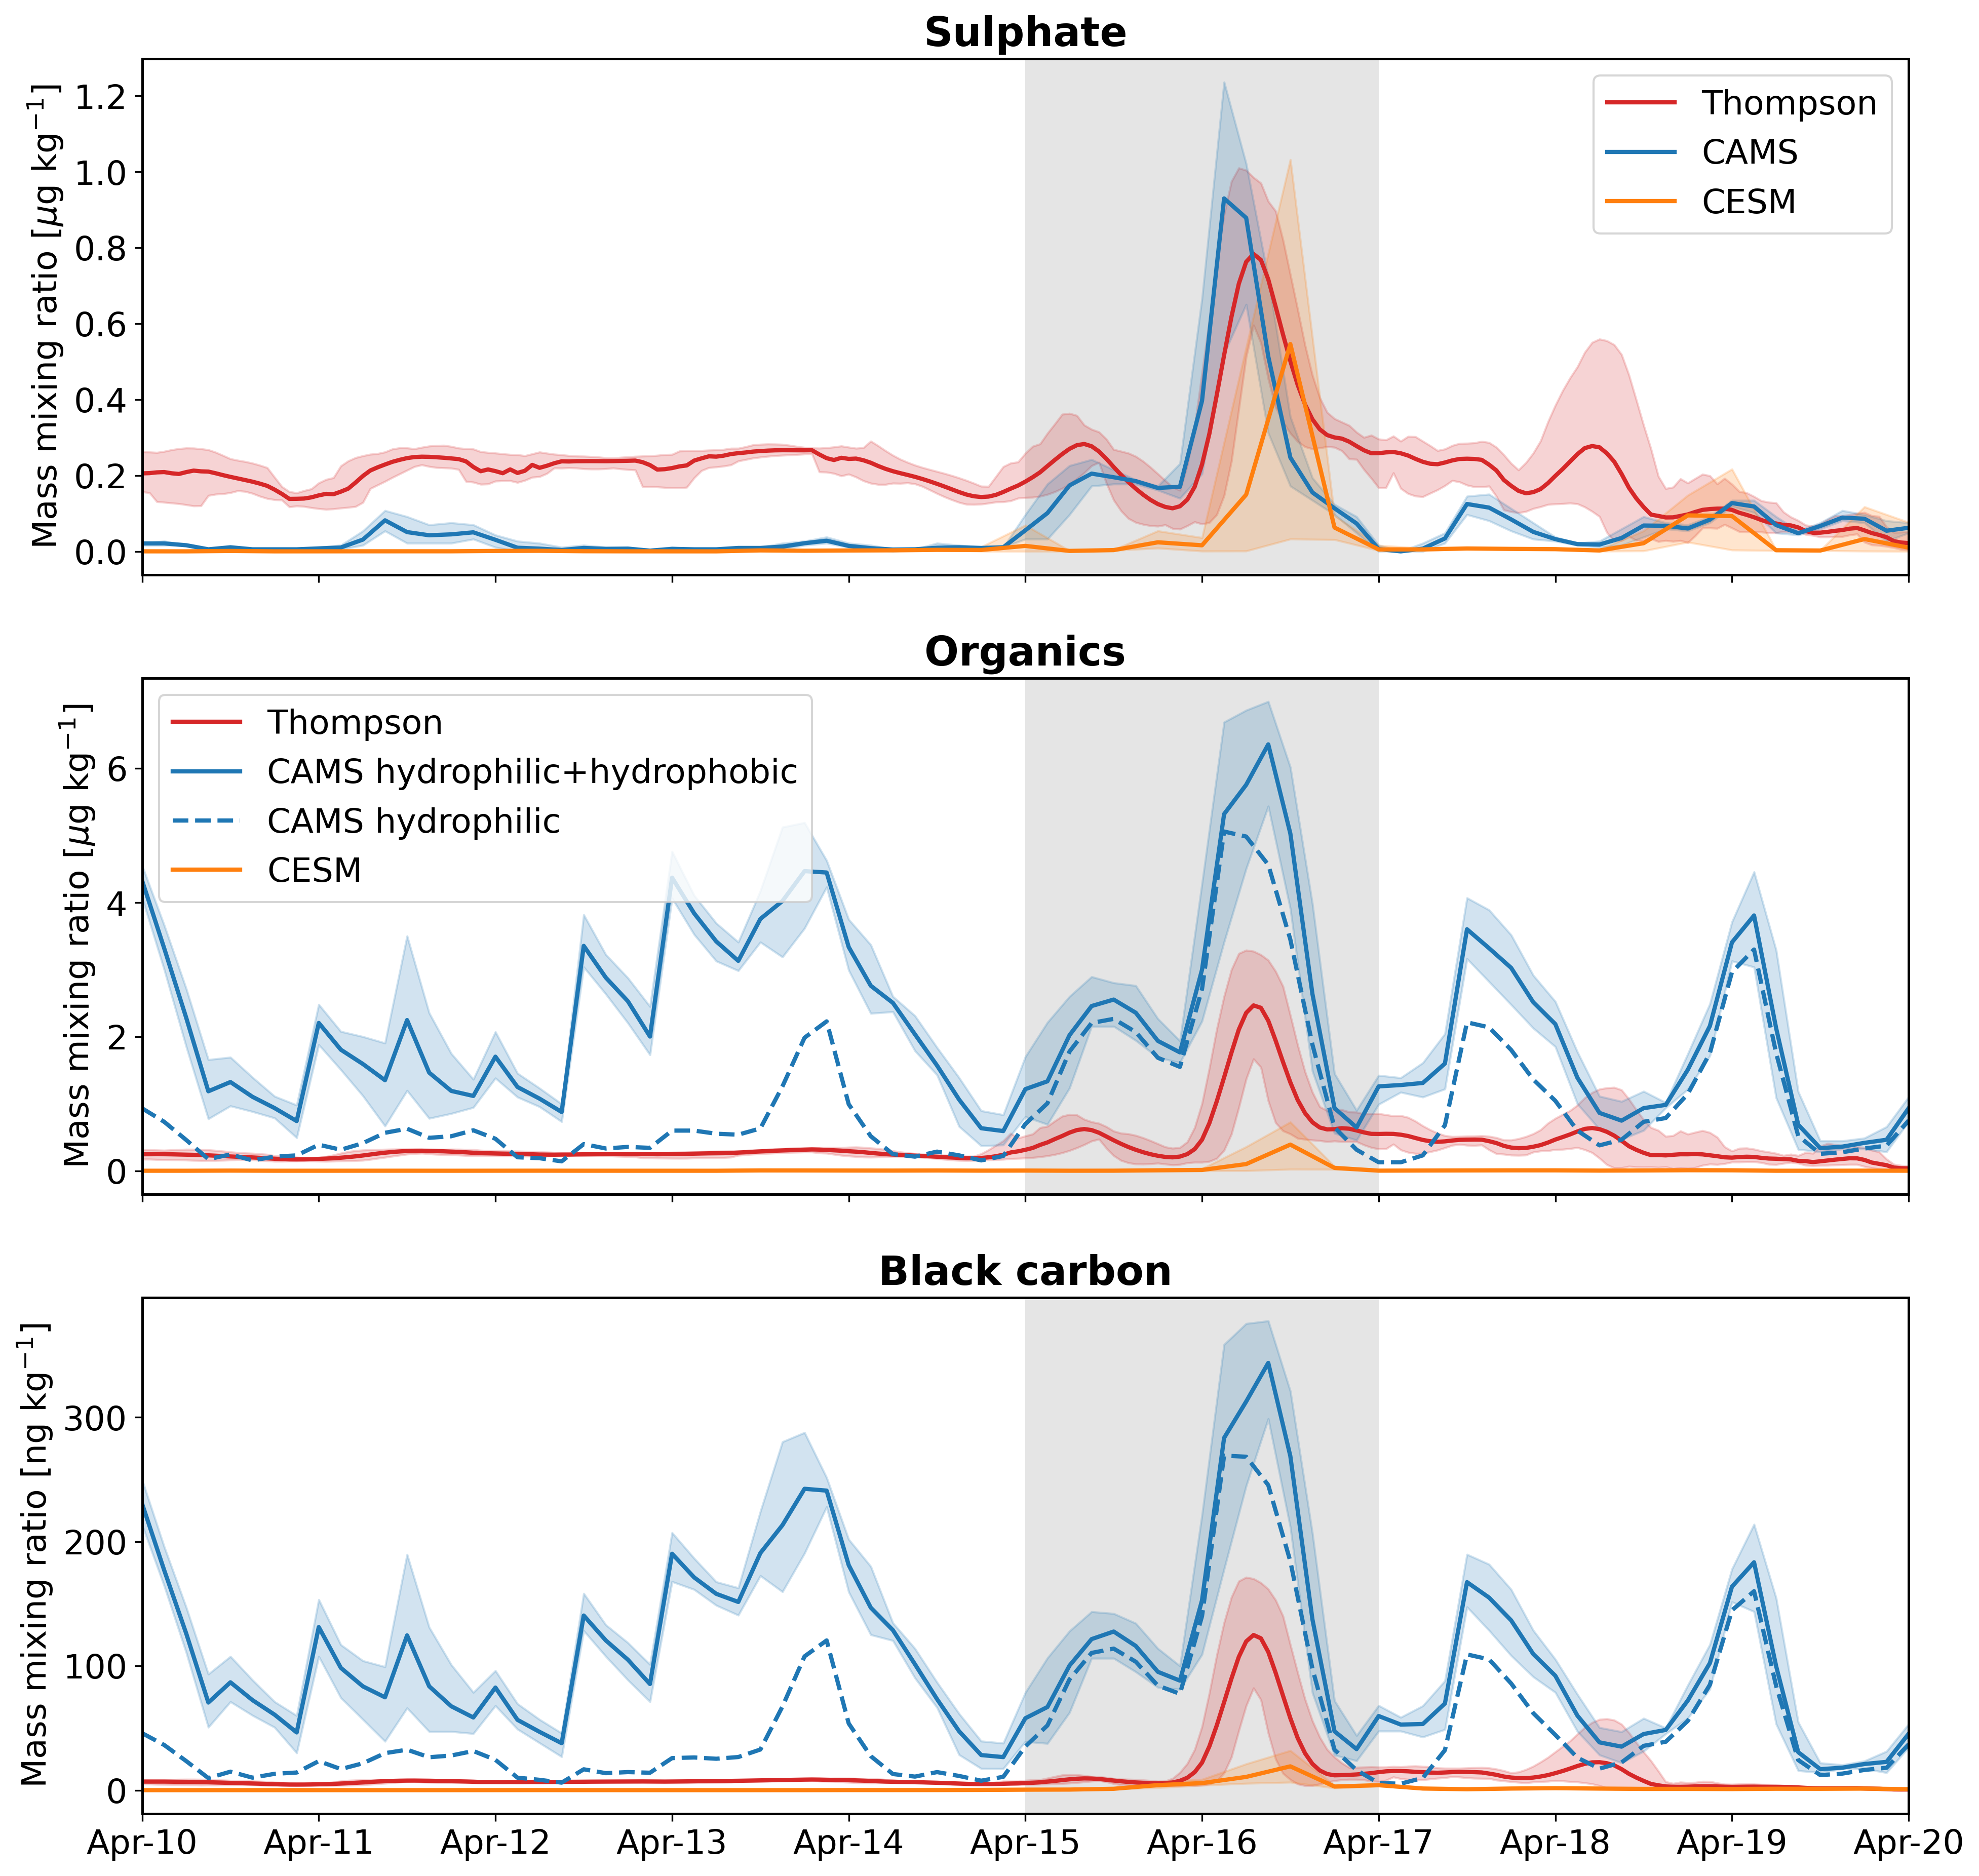

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15,15), dpi=300)

for ax in axes:
    ax.axvspan(
        dt.datetime(2020,4,15),
        dt.datetime(2020,4,17),
        color="black",
        alpha=0.1,
        ec="None"
    )

f_ams = 0.65
std_ams = 0.5

### SULPHATE
axes[0].plot(
    wrfout.Time,
    wrfout_mosaic_mean.so4_mmr.isel(bottom_top=0),
    c="tab:red",
    label="Thompson"
)
axes[0].fill_between(
    wrfout.Time,
    wrfout_mosaic_min.so4_mmr.isel(bottom_top=0),
    wrfout_mosaic_max.so4_mmr.isel(bottom_top=0),
    color="tab:red",
    alpha=0.2,
)
axes[0].plot(
    cams.time,
    1e9*cams_mosaic_mean.so4,
    c="tab:blue",
    label="CAMS"
)
axes[0].fill_between(
    cams.time,
    1e9*cams_mosaic_min.so4,
    1e9*cams_mosaic_max.so4,
    color="tab:blue",
    alpha=0.2,
)
axes[0].plot(
    cesm.time,
    1e9*cesm_mosaic_mean.so4.isel(lev=-1),
    c="tab:orange",
    label="CESM"
)
axes[0].fill_between(
    cesm.time,
    1e9*cesm_mosaic_min.so4.isel(lev=-1),
    1e9*cesm_mosaic_max.so4.isel(lev=-1),
    color="tab:orange",
    alpha=0.2,
)

axes[0].set_ylabel("Mass mixing ratio [$\\mu$g kg$^{{-1}}$]")
axes[0].set_title("Sulphate", weight="bold")

### OC
axes[1].plot(
    wrfout.Time,
    (wrfout_mosaic_mean.toa_mmr+wrfout_mosaic_mean.oc_mmr).isel(bottom_top=0),
    c="tab:red",
    label="Thompson"
)
axes[1].fill_between(
    wrfout.Time,
    (wrfout_mosaic_min.toa_mmr+wrfout_mosaic_min.oc_mmr).isel(bottom_top=0),
    (wrfout_mosaic_max.toa_mmr+wrfout_mosaic_max.oc_mmr).isel(bottom_top=0),
    color="tab:red",
    alpha=0.2,
)
axes[1].plot(
    cams.time,
    1e9*(cams_mosaic_mean.oc_hydrophilic+cams_mosaic_mean.oc_hydrophobic),
    c="tab:blue",
    label="CAMS hydrophilic+hydrophobic"
)
axes[1].plot(
    cams.time,
    1e9*cams_mosaic_mean.oc_hydrophilic,
    c="tab:blue",
    ls="dashed",
    label="CAMS hydrophilic"
)
axes[1].fill_between(
    cams.time,
    1e9*(cams_mosaic_min.oc_hydrophilic+cams_mosaic_min.oc_hydrophobic),
    1e9*(cams_mosaic_max.oc_hydrophilic+cams_mosaic_max.oc_hydrophobic),
    color="tab:blue",
    alpha=0.2,
)
axes[1].plot(
    cesm.time,
    1e9*cesm_mosaic_mean.oc.isel(lev=-1),
    c="tab:orange",
    label="CESM"
)
axes[1].fill_between(
    cesm.time,
    1e9*cesm_mosaic_min.oc.isel(lev=-1),
    1e9*cesm_mosaic_max.oc.isel(lev=-1),
    color="tab:orange",
    alpha=0.2,
)
axes[1].set_ylabel("Mass mixing ratio [$\\mu$g kg$^{{-1}}$]")
axes[1].set_title("Organics", weight="bold")

### BC
axes[2].plot(
    wrfout.Time,
    wrfout_mosaic_mean.bc_mmr.isel(bottom_top=0)*1e3,
    c="tab:red",
    label="Thompson"
)
axes[2].fill_between(
    wrfout.Time,
    wrfout_mosaic_min.bc_mmr.isel(bottom_top=0)*1e3,
    wrfout_mosaic_max.bc_mmr.isel(bottom_top=0)*1e3,
    color="tab:red",
    alpha=0.2,
)
axes[2].plot(
    cams.time,
    1e12*(cams_mosaic_mean.bc_hydrophilic+cams_mosaic_mean.bc_hydrophobic),
    c="tab:blue",
    label="CAMS all"
)
axes[2].plot(
    cams.time,
    1e12*cams_mosaic_mean.bc_hydrophilic,
    c="tab:blue",
    ls="dashed",
    label="CAMS hydrophilic"
)
axes[2].fill_between(
    cams.time,
    1e12*(cams_mosaic_min.bc_hydrophilic+cams_mosaic_min.bc_hydrophobic),
    1e12*(cams_mosaic_max.bc_hydrophilic+cams_mosaic_max.bc_hydrophobic),
    color="tab:blue",
    alpha=0.2,
)
axes[2].plot(
    cesm.time,
    1e12*cesm_mosaic_mean.bc.isel(lev=-1),
    c="tab:orange",
    label="CESM"
)
axes[2].fill_between(
    cesm.time,
    1e12*cesm_mosaic_min.bc.isel(lev=-1),
    1e12*cesm_mosaic_max.bc.isel(lev=-1),
    color="tab:orange",
    alpha=0.2,
)
axes[2].set_ylabel("Mass mixing ratio [ng kg$^{{-1}}$]")
axes[2].set_title("Black carbon", weight="bold")

axes[0].legend()
axes[1].legend()
for ax in axes:
    ax.set_xlim(apr.start, apr.stop)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
for ax in axes[:-1]:
    ax.set_xticklabels([])

plt.savefig(f"figures/aero-mmr-cesm-cams.png", bbox_inches="tight")

### mass concentration
calculate mass concentrations from CAMS and CESM by interpolating onto WRF-Chem-Polar timesteps and using WRF-Chem-Polar air density to convert

In [35]:
cams_mass_conc_mean = cams_mosaic_mean.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cams_mass_conc_min = cams_mosaic_min.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cams_mass_conc_max = cams_mosaic_max.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_mean = cesm_mosaic_mean.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_min = cesm_mosaic_min.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_max = cesm_mosaic_max.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)

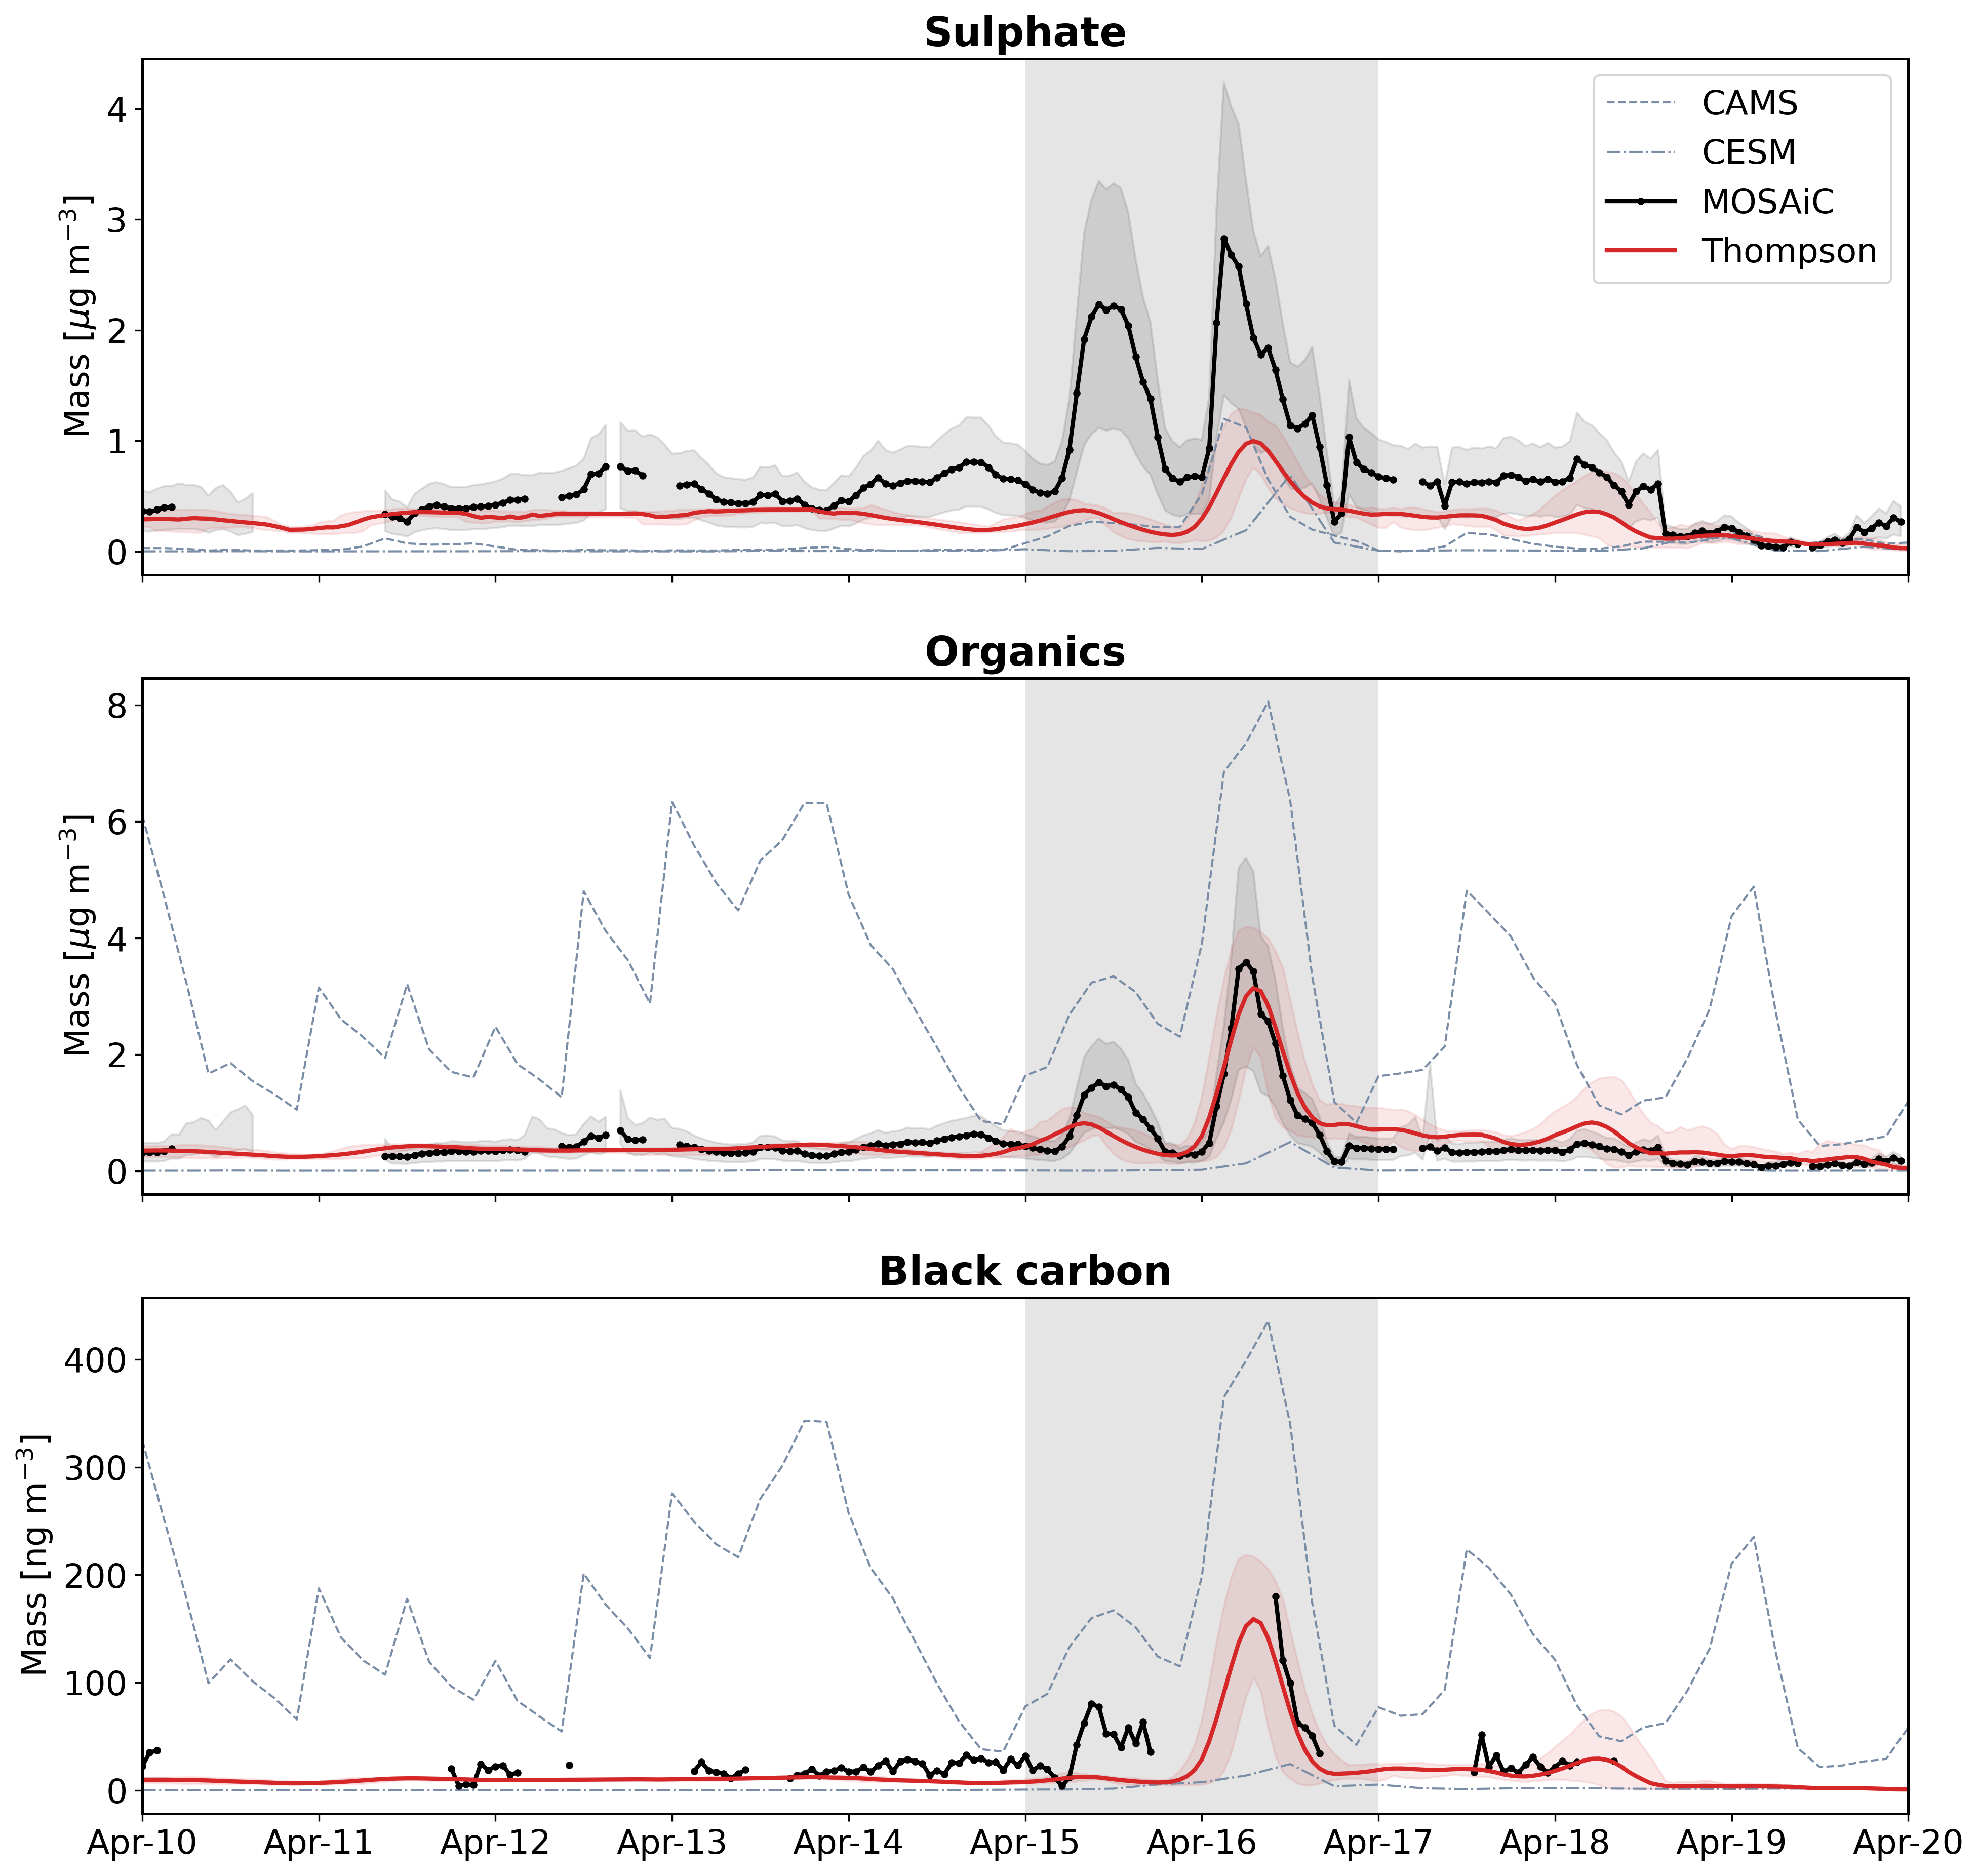

In [64]:
alpha, lw, ms = 0.1, 1, 5
c_input_data = "#7A8DA6"

fig, axes = plt.subplots(3, 1, figsize=(15,15), dpi=300)

for ax in axes:
    ax.axvspan(
        dt.datetime(2020,4,15),
        dt.datetime(2020,4,17),
        color="black",
        alpha=0.1,
        ec="None"
    )

f_ams = 0.65
std_ams = 0.5

### SULPHATE
axes[0].plot(
    wrfout.Time,
    1e9*cams_mass_conc_mean.so4,
    c=c_input_data,
    # marker=".",
    # ms=3,
    ls="dashed",
    label="CAMS",
    linewidth=lw,
)
axes[0].plot(
    wrfout.Time,
    1e9*cesm_mass_conc_mean.so4.isel(lev=-1),
    c=c_input_data,
    # marker="s",
    # ms=3,
    ls="dashdot",
    label="CESM",
    linewidth=lw
)
axes[0].fill_between(
    ams_masked_1h.time,
    f_ams*ams_data_1h.so4-std_ams*f_ams*ams_data_1h.so4,
    f_ams*ams_data_1h.so4+std_ams*f_ams*ams_data_1h.so4,
    color="k",
    alpha=alpha,
)
axes[0].plot(
    ams_masked_1h.time,
    f_ams*ams_masked_1h.so4,
    'k',
    label='MOSAiC',
    marker=".",
    ms=ms,
)
axes[0].plot(
    wrfout.Time,
    wrfout_mosaic_mean.so4.isel(bottom_top=0),
    c="tab:red",
    label="Thompson"
)
axes[0].fill_between(
    wrfout.Time,
    wrfout_mosaic_min.so4.isel(bottom_top=0),
    wrfout_mosaic_max.so4.isel(bottom_top=0),
    color="tab:red",
    alpha=alpha,
)

axes[0].set_ylabel("Mass [$\\mu$g m$^{{-3}}$]")
axes[0].set_title("Sulphate", weight="bold")

### OC

axes[1].plot(
    wrfout.Time,
    1e9*(cams_mass_conc_mean.oc_hydrophilic+cams_mass_conc_mean.oc_hydrophobic),
    c=c_input_data,
    ls="dashed",
    linewidth=lw,
    label="CAMS hydrophilic+hydrophobic"
)
axes[1].plot(
    wrfout.Time,
    1e9*cesm_mass_conc_mean.oc.isel(lev=-1),
    c=c_input_data,
    ls="dashdot",
    linewidth=lw,
)
axes[1].fill_between(
    ams_masked_1h.time,
    f_ams*ams_data_1h.org-std_ams*f_ams*ams_data_1h.org,
    f_ams*ams_data_1h.org+std_ams*f_ams*ams_data_1h.org,
    color="k",
    alpha=alpha,
)
axes[1].plot(
    ams_masked_1h.time,
    f_ams*ams_masked_1h.org,
    'k',
    marker=".",
    ms=ms,
)
axes[1].plot(
    wrfout.Time,
    (wrfout_mosaic_mean.toa+wrfout_mosaic_mean.oc).isel(bottom_top=0),
    c="tab:red",
)
axes[1].fill_between(
    wrfout.Time,
    (wrfout_mosaic_min.toa+wrfout_mosaic_min.oc).isel(bottom_top=0),
    (wrfout_mosaic_max.toa+wrfout_mosaic_max.oc).isel(bottom_top=0),
    color="tab:red",
    alpha=alpha,
)
axes[1].set_ylabel("Mass [$\\mu$g m$^{{-3}}$]")
axes[1].set_title("Organics", weight="bold")

### BC

axes[2].plot(
    wrfout.Time,
    1e12*(cams_mass_conc_mean.bc_hydrophilic+cams_mass_conc_mean.bc_hydrophobic),
    c=c_input_data,
    label="CAMS all",
    ls="dashed",
    linewidth=lw
)
axes[2].plot(
    wrfout.Time,
    1e12*cesm_mass_conc_mean.bc.isel(lev=-1),
    c=c_input_data,
    ls="dashdot",
    linewidth=lw
)
axes[2].plot(
    ebc_masked_1h.time,
    f_ams*ebc_masked_1h,
    'k',
    marker=".",
    ms=ms,
)
axes[2].plot(
    wrfout.Time,
    wrfout_mosaic_mean.bc.isel(bottom_top=0)*1e3,
    c="tab:red",
)
axes[2].fill_between(
    wrfout.Time,
    wrfout_mosaic_min.bc.isel(bottom_top=0)*1e3,
    wrfout_mosaic_max.bc.isel(bottom_top=0)*1e3,
    color="tab:red",
    alpha=alpha,
)
axes[2].set_ylabel("Mass [ng m$^{{-3}}$]")
axes[2].set_title("Black carbon", weight="bold")

axes[0].legend()
for ax in axes:
    ax.set_xlim(apr.start, apr.stop)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
for ax in axes[:-1]:
    ax.set_xticklabels([])

plt.savefig(f"figures/aero-mass-cesm-cams.png", bbox_inches="tight")
